In [1]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load ARFF
data, meta = arff.loadarff("adult.arff")

df = pd.DataFrame(data)

# Decode byte strings
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode("utf-8")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nFirst rows:")
display(df.head())

Shape:
(32561, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Dtypes:
age               float64
workclass          object
fnlwgt            float64
education          object
education-num     float64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country     object
income             object
dtype: object

First rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [3]:
print(df.isna().sum())

# Sometimes Adult uses '?' instead of NaN
for col in df.columns:
    if df[col].dtype == object:
        n_q = (df[col] == "?").sum()
        if n_q > 0:
            print(f"{col}: {n_q} '?' values")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
workclass: 1836 '?' values
occupation: 1843 '?' values
native-country: 583 '?' values


In [4]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [5]:
categorical_cols = []
continuous_cols = []

for col in df.columns:
    if df[col].dtype == object:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

print("Categorical:")
print(categorical_cols)

print("\nContinuous:")
print(continuous_cols)

Categorical:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Continuous:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [6]:
for col in categorical_cols:
    print(f"\n{col}")
    print(f"unique={df[col].nunique()}")
    print(df[col].value_counts().head())


workclass
unique=9
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Name: count, dtype: int64

education
unique=16
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64

marital-status
unique=7
marital-status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64

occupation
unique=15
occupation
Prof-specialty     4140
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

relationship
unique=6
relationship
Husband          13193
Not-in-family     8305
Own-child         5068
Unmarried         3446
Wife              1568
Name: count, dtype: int64

race
unique=5
race
White                 27816
Black                  3124
Asian-Pac

In [7]:
display(df[continuous_cols].describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


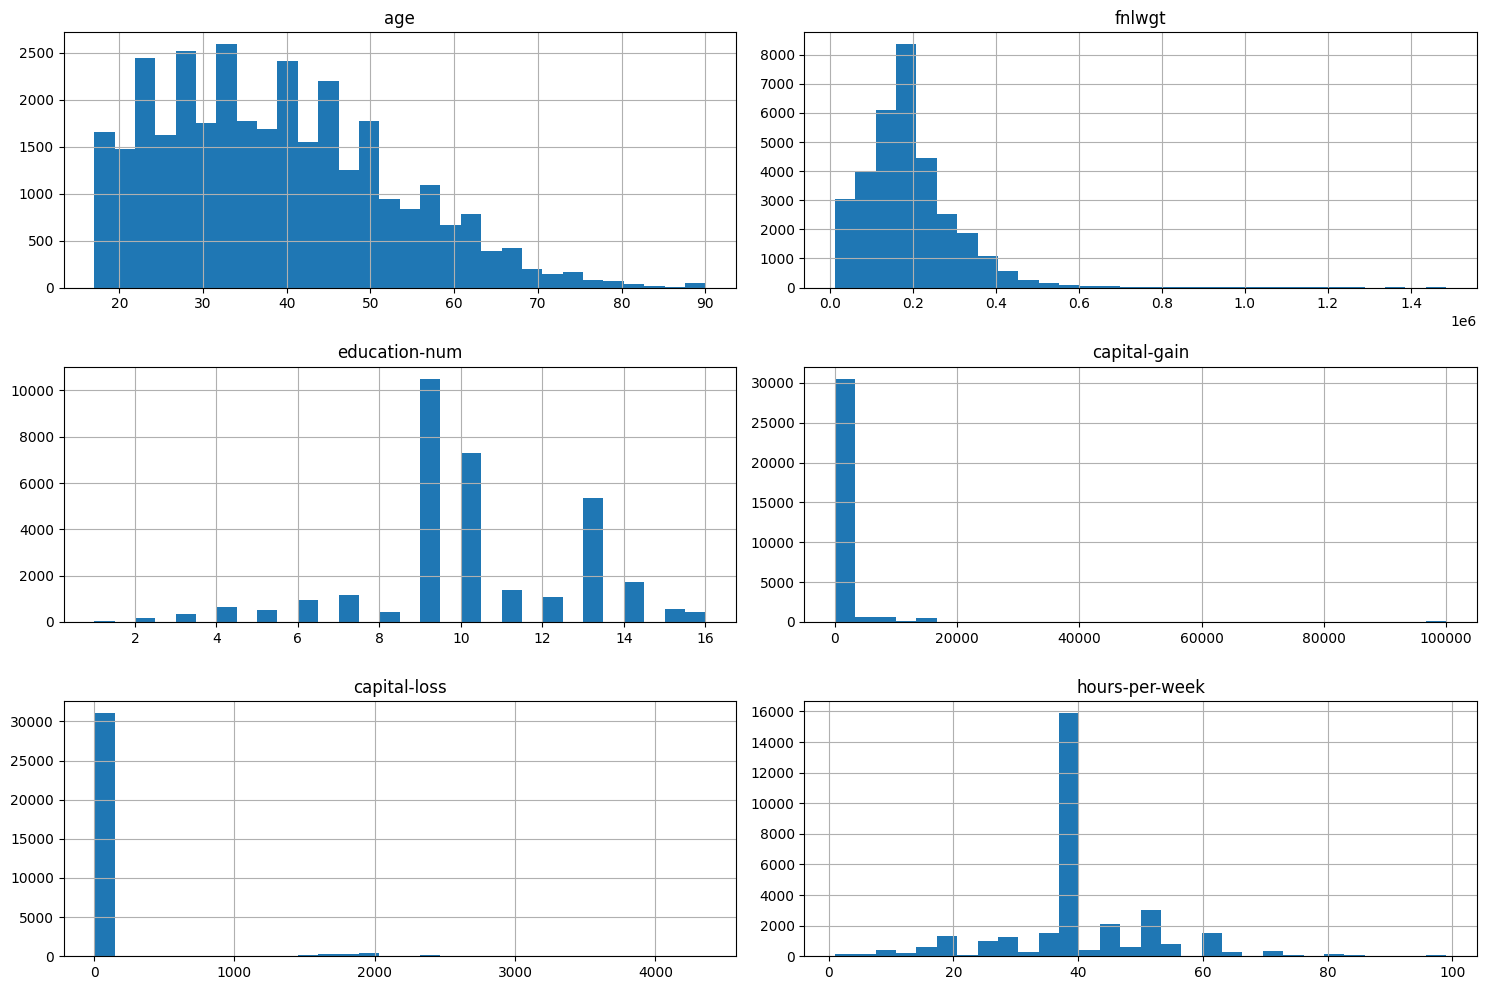

In [8]:
df[continuous_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

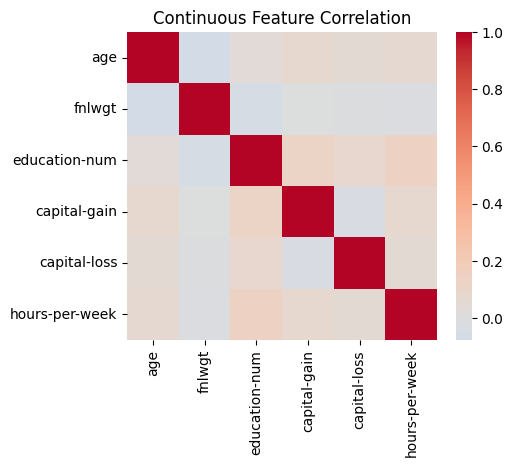

In [9]:
corr = df[continuous_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Continuous Feature Correlation")
plt.show()

# Preprocessing

In [10]:
continuous_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# replace missing values
df = df.replace("?", "Unknown")

target_col = "income"

X = df.drop(columns=[target_col])
y = (df[target_col] == ">50K").astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), continuous_cols),
        (
            "cat",
            OneHotEncoder(
                sparse_output=False,
                handle_unknown="ignore"
            ),
            categorical_cols
        ),
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (26048, 108)
Test shape: (6513, 108)


In [12]:
y_train.value_counts()

income
0    19775
1     6273
Name: count, dtype: int64

In [13]:
encoder = preprocessor.named_transformers_["cat"]

for col, cats in zip(categorical_cols, encoder.categories_):
    print(col, len(cats))

workclass 9
education 16
marital-status 7
occupation 15
relationship 6
race 5
sex 2
native-country 42


In [14]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True
)

print("Input dim:", X_train_tensor.shape[1])
print("Num batches:", len(train_loader))

Input dim: 108
Num batches: 101


# Models classes

In [95]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Linear(256, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        logits = self.classifier(features)

        if return_features:
            return logits, features

        return logits

# Main

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 108
noise_dim = 128

G = Generator(noise_dim, input_dim).to(device)
D = Discriminator(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = torch.optim.Adam(
    G.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    D.parameters(),
    lr=1e-4,
    betas=(0.5, 0.999)
)

In [17]:
num_epochs = 50

G_losses = []
D_losses = []

for epoch in range(num_epochs):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for (real_batch,) in train_loader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -----------------
        # Train Discriminator
        # -----------------
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z).detach()

        D_real = D(real_batch)
        D_fake = D(fake_batch)

        D_loss_real = criterion(D_real, real_labels)
        D_loss_fake = criterion(D_fake, fake_labels)
        D_loss = D_loss_real + D_loss_fake

        optimizer_D.zero_grad()
        D_loss.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z)

        D_fake = D(fake_batch)

        G_loss = criterion(D_fake, real_labels)

        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()

        epoch_D_loss += D_loss.item()
        epoch_G_loss += G_loss.item()

    epoch_D_loss /= len(train_loader)
    epoch_G_loss /= len(train_loader)

    D_losses.append(epoch_D_loss)
    G_losses.append(epoch_G_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"D_loss: {epoch_D_loss:.4f} "
            f"G_loss: {epoch_G_loss:.4f}"
        )
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            D_real_score = torch.sigmoid(D(real_batch)).mean().item()
            D_fake_score = torch.sigmoid(D(fake_batch)).mean().item()

        print(
            f"D(real)={D_real_score:.3f} "
            f"D(fake)={D_fake_score:.3f}"
        )

D(real)=0.500 D(fake)=0.496
Epoch [10/50] D_loss: 1.3810 G_loss: 0.6985
D(real)=0.499 D(fake)=0.500
D(real)=0.513 D(fake)=0.497
Epoch [20/50] D_loss: 1.3710 G_loss: 0.7283
D(real)=0.494 D(fake)=0.446
D(real)=0.518 D(fake)=0.489
Epoch [30/50] D_loss: 1.3501 G_loss: 0.7241
D(real)=0.506 D(fake)=0.482
D(real)=0.514 D(fake)=0.481
Epoch [40/50] D_loss: 1.3456 G_loss: 0.7224
D(real)=0.518 D(fake)=0.488
D(real)=0.515 D(fake)=0.479
Epoch [50/50] D_loss: 1.3371 G_loss: 0.7439
D(real)=0.516 D(fake)=0.495


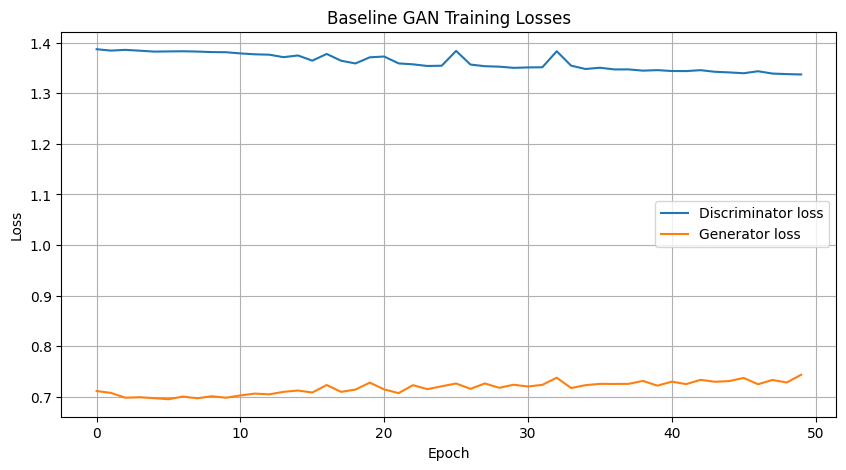

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(D_losses, label="Discriminator loss")
plt.plot(G_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

[ 0.07509798  0.18837789  0.031362   -0.12888274 -0.19856668 -0.60099703
 -0.16452947 -0.02139912 -0.12720542  0.9971625 ]
[0.7777091  0.90929025 1.0135314  0.04119473 0.03868517 0.7678732
 0.11236154 0.12951772 0.08908268 0.35072836]


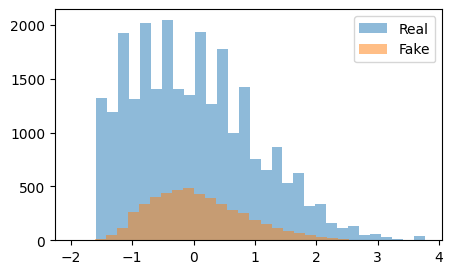

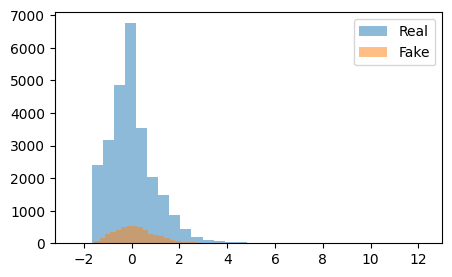

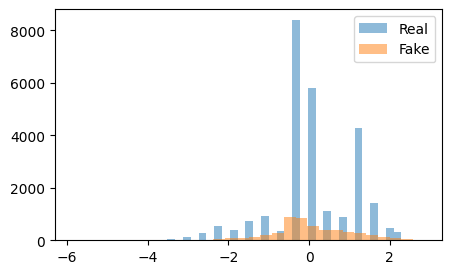

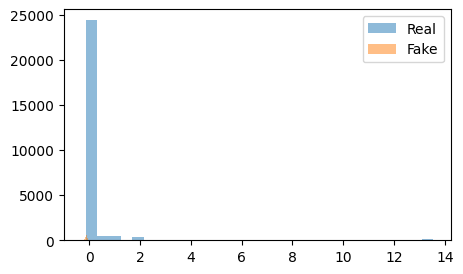

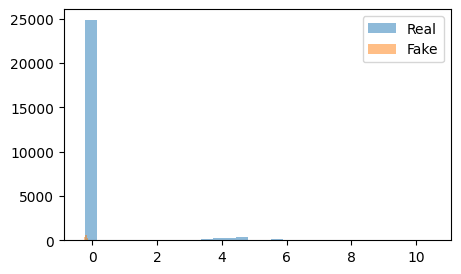

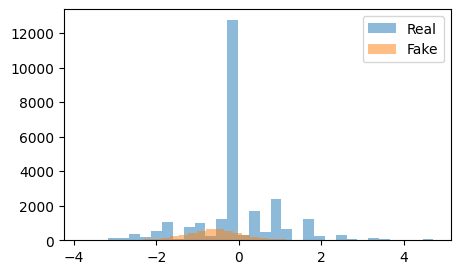

In [19]:
G.eval()

with torch.no_grad():
    z = torch.randn(5000, noise_dim, device=device)
    synth = G(z).cpu().numpy()

print(synth.mean(axis=0)[:10])
print(synth.std(axis=0)[:10])

real_cont = X_train[:, :6]
fake_cont = synth[:, :6]

for i in range(6):
    plt.figure(figsize=(5,3))
    
    plt.hist(
        real_cont[:, i],
        bins=30,
        alpha=0.5,
        label="Real"
    )
    
    plt.hist(
        fake_cont[:, i],
        bins=30,
        alpha=0.5,
        label="Fake"
    )
    
    plt.legend()
    plt.show()

In [20]:
print(fake_cont.std(axis=0))
print(real_cont.std(axis=0))


[0.7777091  0.90929025 1.0135314  0.04119473 0.03868517 0.7678732 ]
[1. 1. 1. 1. 1. 1.]


# Creatig training dataset

In [21]:
G.eval()

n_synth = X_train.shape[0]

with torch.no_grad():
    z = torch.randn(n_synth, noise_dim, device=device)
    X_synth_raw = G(z).cpu().numpy()

print(X_synth_raw.shape)

(26048, 108)


In [22]:
import numpy as np
import pandas as pd

def decode_synthetic(X_synth_raw, preprocessor, continuous_cols, categorical_cols):
    scaler = preprocessor.named_transformers_["num"]
    encoder = preprocessor.named_transformers_["cat"]

    n_cont = len(continuous_cols)

    # continuous part
    X_cont_scaled = X_synth_raw[:, :n_cont]
    X_cont = scaler.inverse_transform(X_cont_scaled)

    decoded = pd.DataFrame(X_cont, columns=continuous_cols)

    # categorical part
    start = n_cont

    for col, categories in zip(categorical_cols, encoder.categories_):
        end = start + len(categories)

        logits_block = X_synth_raw[:, start:end]
        idx = np.argmax(logits_block, axis=1)

        decoded[col] = np.array(categories)[idx]

        start = end

    return decoded

In [23]:
df_synth = decode_synthetic(
    X_synth_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

display(df_synth.head())
display(df_synth.describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,40.348316,195050.750000,14.238453,114.182922,25.324739,24.618155,Private,Bachelors,Married-civ-spouse,Other-service,Husband,White,Male,United-States
1,20.697903,98660.953125,8.683028,-717.315552,-15.992364,25.139797,Private,HS-grad,Never-married,Other-service,Own-child,White,Female,United-States
2,36.344624,49146.281250,12.313084,189.447815,11.626472,37.072021,Private,Bachelors,Married-civ-spouse,Other-service,Husband,White,Male,United-States
3,19.380501,26941.656250,9.444172,-167.767822,-5.786523,46.549892,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
4,32.328152,432973.781250,12.791061,-160.328979,-9.986138,31.749775,Private,Bachelors,Never-married,Craft-repair,Own-child,Black,Male,United-States


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,39.597443,213304.703125,10.190226,113.500923,7.414983,32.938137
std,10.708496,96359.960938,2.578074,300.601257,15.838930,9.234767
min,8.875863,-28129.890625,-5.946224,-2237.048096,-67.612656,-5.114007
25%,31.552247,146056.335938,8.886044,-64.271515,-2.631072,27.231546
50%,38.426643,203584.625000,9.768456,136.139923,6.650023,33.005781
75%,46.320086,269009.390625,11.835363,315.116272,16.406530,38.536783
max,92.814293,762747.187500,18.578079,1522.417725,92.342468,71.453728


In [24]:
for col in categorical_cols:
    print("\n", col)
    print("Real:")
    print(X_train_raw[col].value_counts(normalize=True).head())
    print()
    print("Synthetic:")
    print(df_synth[col].value_counts(normalize=True).head())


 workclass
Real:
workclass
Private             0.694833
Self-emp-not-inc    0.078355
Local-gov           0.065418
Unknown             0.056549
State-gov           0.040425
Name: proportion, dtype: float64

Synthetic:
workclass
Private             0.910051
Self-emp-not-inc    0.066301
Unknown             0.023457
Local-gov           0.000192
Name: proportion, dtype: float64

 education
Real:
education
HS-grad         0.321752
Some-college    0.223280
Bachelors       0.163506
Masters         0.053939
Assoc-voc       0.042537
Name: proportion, dtype: float64

Synthetic:
education
HS-grad         0.342713
Some-college    0.313729
Bachelors       0.207809
Masters         0.073403
11th            0.028294
Name: proportion, dtype: float64

 marital-status
Real:
marital-status
Married-civ-spouse    0.460650
Never-married         0.326397
Divorced              0.136671
Separated             0.031711
Widowed               0.031135
Name: proportion, dtype: float64

Synthetic:
marital-status
Marr

In [25]:
for col in categorical_cols:
    print(
        f"{col}: "
        f"real={X_train_raw[col].nunique()} "
        f"synth={df_synth[col].nunique()}"
    )

workclass: real=9 synth=4
education: real=16 synth=12
marital-status: real=7 synth=5
occupation: real=15 synth=8
relationship: real=6 synth=5
race: real=5 synth=3
sex: real=2 synth=2
native-country: real=42 synth=13


# Detection metric

In [26]:
real_label = 0
fake_label = 1

In [27]:
X_synth = preprocessor.transform(df_synth)

X_det = np.vstack([
    X_train,
    X_synth
])

y_det = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_synth))
])

In [28]:
X_det.shape

(52096, 108)

In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

aucs = []

for train_idx, test_idx in skf.split(X_det, y_det):

    X_tr = X_det[train_idx]
    X_te = X_det[test_idx]

    y_tr = y_det[train_idx]
    y_te = y_det[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)

    probs = rf.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, probs)

    aucs.append(auc)

print("Detection AUCs:", aucs)
print("Mean Detection AUC:", np.mean(aucs))

Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0


In [30]:
X_det_cont = np.vstack([
    X_train[:, :6],
    X_synth[:, :6]
])

y_det = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_synth))
])

# same RF cross validation

In [31]:
cat_part = X_synth[:, 6:]

always_zero = np.where((cat_part == 0).all(axis=0))[0]

print("Always zero categorical columns:", len(always_zero))

Always zero categorical columns: 50


In [32]:
start = 6

for col, cats in zip(
    categorical_cols,
    preprocessor.named_transformers_["cat"].categories_
):
    end = start + len(cats)

    block = X_synth[:, start:end]

    active = np.sum(block.sum(axis=0) > 0)

    print(
        f"{col}: "
        f"{active}/{len(cats)} categories generated"
    )

    start = end

workclass: 4/9 categories generated
education: 12/16 categories generated
marital-status: 5/7 categories generated
occupation: 8/15 categories generated
relationship: 5/6 categories generated
race: 3/5 categories generated
sex: 2/2 categories generated
native-country: 13/42 categories generated


# Efficacy

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# Real baseline
rf_real = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_real.fit(X_train, y_train)

real_probs = rf_real.predict_proba(X_test)[:, 1]
auc_real = roc_auc_score(y_test, real_probs)

print("AUC real train -> real test:", auc_real)

AUC real train -> real test: 0.9079627819277357


In [34]:
rng = np.random.default_rng(42)

y_synth = rng.choice(
    y_train,
    size=len(X_synth),
    replace=True
)

rf_synth = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_synth.fit(X_synth, y_synth)

synth_probs = rf_synth.predict_proba(X_test)[:, 1]
auc_synth = roc_auc_score(y_test, synth_probs)

efficacy = auc_synth / auc_real

print("AUC synthetic train -> real test:", auc_synth)
print("Efficacy:", efficacy)

AUC synthetic train -> real test: 0.5026473607643259
Efficacy: 0.5535990800164002


# CGAN

In [35]:
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

cgan_dataset = TensorDataset(X_train_tensor, y_train_tensor)

cgan_loader = DataLoader(
    cgan_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True
)

In [36]:
import torch.nn as nn
import torch.nn.functional as F

class ConditionalGenerator(nn.Module):
    def __init__(self, noise_dim, condition_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim + condition_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, output_dim)
        )

    def forward(self, z, y):
        y_onehot = F.one_hot(y, num_classes=2).float()
        x = torch.cat([z, y_onehot], dim=1)
        return self.net(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, input_dim, condition_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim + condition_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1)
        )

    def forward(self, x, y):
        y_onehot = F.one_hot(y, num_classes=2).float()
        x = torch.cat([x, y_onehot], dim=1)
        return self.net(x)

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train.shape[1]
noise_dim = 128
condition_dim = 2

cG = ConditionalGenerator(noise_dim, condition_dim, input_dim).to(device)
cD = ConditionalDiscriminator(input_dim, condition_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_cG = torch.optim.Adam(
    cG.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optimizer_cD = torch.optim.Adam(
    cD.parameters(),
    lr=1e-4,
    betas=(0.5, 0.999)
)

In [38]:
num_epochs = 50

cG_losses = []
cD_losses = []

for epoch in range(num_epochs):
    epoch_cG_loss = 0
    epoch_cD_loss = 0

    for real_batch, y_batch in cgan_loader:
        real_batch = real_batch.to(device)
        y_batch = y_batch.to(device)

        batch_size = real_batch.size(0)

        real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train Conditional Discriminator
        # -------------------------
        z = torch.randn(batch_size, noise_dim, device=device)

        fake_batch = cG(z, y_batch).detach()

        cD_real = cD(real_batch, y_batch)
        cD_fake = cD(fake_batch, y_batch)

        cD_loss_real = criterion(cD_real, real_labels)
        cD_loss_fake = criterion(cD_fake, fake_labels)

        cD_loss = cD_loss_real + cD_loss_fake

        optimizer_cD.zero_grad()
        cD_loss.backward()
        optimizer_cD.step()

        # -------------------------
        # Train Conditional Generator
        # -------------------------
        for _ in range(2):
            z = torch.randn(batch_size, noise_dim, device=device)

            fake_batch = cG(z, y_batch)

            cD_fake = cD(fake_batch, y_batch)

            cG_loss = criterion(cD_fake, real_labels)

            optimizer_cG.zero_grad()
            cG_loss.backward()
            optimizer_cG.step()

        epoch_cD_loss += cD_loss.item()
        epoch_cG_loss += cG_loss.item()

    epoch_cD_loss /= len(cgan_loader)
    epoch_cG_loss /= len(cgan_loader)

    cD_losses.append(epoch_cD_loss)
    cG_losses.append(epoch_cG_loss)

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            cD_real_score = torch.sigmoid(cD(real_batch, y_batch)).mean().item()
            cD_fake_score = torch.sigmoid(cD(fake_batch, y_batch)).mean().item()

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"cD_loss: {epoch_cD_loss:.4f} "
            f"cG_loss: {epoch_cG_loss:.4f} "
            f"cD(real): {cD_real_score:.3f} "
            f"cD(fake): {cD_fake_score:.3f}"
        )

Epoch [10/50] cD_loss: 1.3779 cG_loss: 0.7715 cD(real): 0.455 cD(fake): 0.454
Epoch [20/50] cD_loss: 1.3758 cG_loss: 0.7801 cD(real): 0.455 cD(fake): 0.450
Epoch [30/50] cD_loss: 1.3753 cG_loss: 0.7829 cD(real): 0.455 cD(fake): 0.452
Epoch [40/50] cD_loss: 1.3753 cG_loss: 0.7867 cD(real): 0.450 cD(fake): 0.446
Epoch [50/50] cD_loss: 1.3617 cG_loss: 0.7882 cD(real): 0.451 cD(fake): 0.492


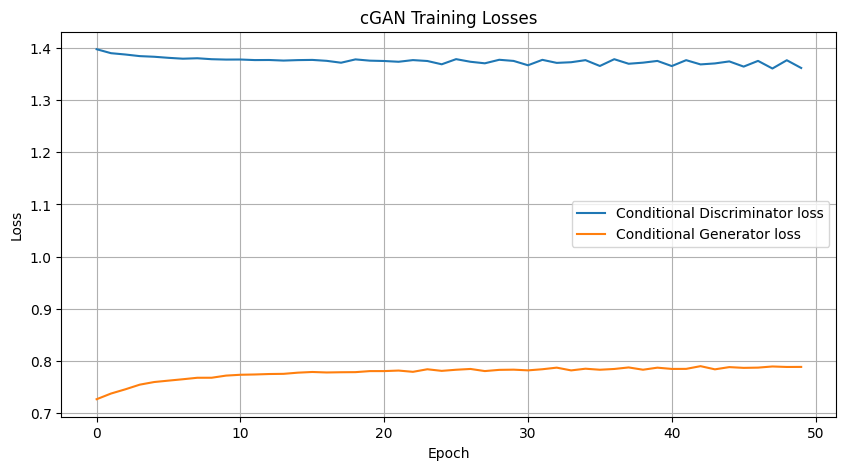

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cD_losses, label="Conditional Discriminator loss")
plt.plot(cG_losses, label="Conditional Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cGAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
cG.eval()

n_synth = X_train.shape[0]

rng = np.random.default_rng(42)

y_synth_cgan_np = rng.choice(
    y_train.values,
    size=n_synth,
    replace=True
)

y_synth_cgan = torch.tensor(
    y_synth_cgan_np,
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    z = torch.randn(n_synth, noise_dim, device=device)
    X_synth_cgan_raw = cG(z, y_synth_cgan).cpu().numpy()

df_synth_cgan = decode_synthetic(
    X_synth_cgan_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

X_synth_cgan = preprocessor.transform(df_synth_cgan)

print(X_synth_cgan.shape)
print(pd.Series(y_synth_cgan_np).value_counts(normalize=True))

(26048, 108)
0    0.753762
1    0.246238
Name: proportion, dtype: float64


In [41]:
for col in categorical_cols:
    print(
        f"{col}: "
        f"real={X_train_raw[col].nunique()} "
        f"cGAN={df_synth_cgan[col].nunique()}"
    )

workclass: real=9 cGAN=6
education: real=16 cGAN=15
marital-status: real=7 cGAN=6
occupation: real=15 cGAN=13
relationship: real=6 cGAN=5
race: real=5 cGAN=3
sex: real=2 cGAN=2
native-country: real=42 cGAN=11


In [42]:
X_det_cgan = np.vstack([
    X_train,
    X_synth_cgan
])

y_det_cgan = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_synth_cgan))
])

In [43]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

aucs = []

for train_idx, test_idx in skf.split(X_det_cgan, y_det_cgan):

    X_tr = X_det_cgan[train_idx]
    X_te = X_det_cgan[test_idx]

    y_tr = y_det_cgan[train_idx]
    y_te = y_det_cgan[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)

    probs = rf.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, probs)

    aucs.append(auc)

print("Detection AUCs:", aucs)
print("Mean Detection AUC:", np.mean(aucs))

Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0


In [44]:
rng = np.random.default_rng(42)


rf_synth = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_synth.fit(X_synth_cgan, y_synth_cgan_np)

synth_probs = rf_synth.predict_proba(X_test)[:, 1]
auc_synth = roc_auc_score(y_test, synth_probs)

efficacy = auc_synth / auc_real

print("AUC synthetic train -> real test:", auc_synth)
print("Efficacy:", efficacy)

AUC synthetic train -> real test: 0.8304821144838117
Efficacy: 0.9146653706670428


# Gumble Softmax

In [45]:
cat_dims = [
    len(cats)
    for cats in preprocessor.named_transformers_["cat"].categories_
]

print(cat_dims)
print(sum(cat_dims))

[9, 16, 7, 15, 6, 5, 2, 42]
102


In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class StructuredGenerator(nn.Module):
    def __init__(
        self,
        noise_dim,
        n_cont,
        cat_dims,
        hidden_dim=512,
        cat_mode="softmax",
        tau=1.0
    ):
        super().__init__()

        self.n_cont = n_cont
        self.cat_dims = cat_dims
        self.cat_mode = cat_mode
        self.tau = tau

        output_dim = n_cont + sum(cat_dims)

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z, return_soft=False):
        raw = self.net(z)

        cont = raw[:, :self.n_cont]
        cat_logits = raw[:, self.n_cont:]

        processed_blocks = []
        soft_blocks = []

        start = 0

        for dim in self.cat_dims:
            end = start + dim
            logits = cat_logits[:, start:end]

            probs = F.softmax(logits, dim=1)
            soft_blocks.append(probs)

            if self.cat_mode == "softmax":
                block = probs

            elif self.cat_mode == "gumbel":
                block = F.gumbel_softmax(
                    logits,
                    tau=self.tau,
                    hard=True,
                    dim=1
                )

            else:
                raise ValueError(f"Unknown cat_mode: {self.cat_mode}")

            processed_blocks.append(block)

            start = end

        out = torch.cat([cont] + processed_blocks, dim=1)

        if return_soft:
            soft_out = torch.cat([cont] + soft_blocks, dim=1)
            return out, soft_out

        return out

In [96]:
def train_structured_gan(
    cat_mode,
    train_loader,
    input_dim,
    noise_dim,
    n_cont,
    cat_dims,
    device,
    num_epochs=50,
    tau=1.0,
    g_updates=2,
    d_updates=1,
    lr_g=2e-4,
    lr_d=1e-4,
    label_smoothing=True,
    use_feature_matching=False,
    lambda_fm=10.0
):
    G = StructuredGenerator(
        noise_dim=noise_dim,
        n_cont=n_cont,
        cat_dims=cat_dims,
        cat_mode=cat_mode,
        tau=tau
    ).to(device)

    D = Discriminator(input_dim).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        epoch_G_loss = 0
        epoch_D_loss = 0

        for (real_batch,) in train_loader:
            real_batch = real_batch.to(device)
            batch_size = real_batch.size(0)

            if label_smoothing:
                real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
                fake_labels = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.1)
            else:
                real_labels = torch.ones(batch_size, 1, device=device)
                fake_labels = torch.zeros(batch_size, 1, device=device)

            # Train D multiple times
            D_loss_total = 0

            for _ in range(d_updates):
                z = torch.randn(batch_size, noise_dim, device=device)
                fake_batch = G(z).detach()

                D_real = D(real_batch)
                D_fake = D(fake_batch)

                D_loss = (
                    criterion(D_real, real_labels)
                    + criterion(D_fake, fake_labels)
                )

                optimizer_D.zero_grad()
                D_loss.backward()
                optimizer_D.step()

                D_loss_total += D_loss.item()

            D_loss_total /= d_updates

            # Train G
            G_loss_total = 0

            for _ in range(g_updates):
                z = torch.randn(batch_size, noise_dim, device=device)
                fake_batch = G(z)

                if use_feature_matching:
                    D_fake_logits, fake_features = D(
                        fake_batch,
                        return_features=True
                    )

                    with torch.no_grad():
                        _, real_features = D(
                            real_batch,
                            return_features=True
                        )

                    adv_loss = criterion(D_fake_logits, real_labels)

                    fm_loss = torch.mean(
                        torch.abs(
                            fake_features.mean(dim=0)
                            - real_features.mean(dim=0)
                        )
                    )

                    G_loss = adv_loss + lambda_fm * fm_loss

                else:
                    D_fake = D(fake_batch)
                    G_loss = criterion(D_fake, real_labels)

                optimizer_G.zero_grad()
                G_loss.backward()
                optimizer_G.step()

                G_loss_total += G_loss.item()

            G_loss_total /= g_updates

            epoch_D_loss += D_loss_total
            epoch_G_loss += G_loss_total

        epoch_D_loss /= len(train_loader)
        epoch_G_loss /= len(train_loader)

        D_losses.append(epoch_D_loss)
        G_losses.append(epoch_G_loss)

        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                z = torch.randn(batch_size, noise_dim, device=device)
                fake_batch = G(z)

                D_real_score = torch.sigmoid(D(real_batch)).mean().item()
                D_fake_score = torch.sigmoid(D(fake_batch)).mean().item()

            print(
                f"[{cat_mode}] Epoch [{epoch+1}/{num_epochs}] "
                f"D_loss={epoch_D_loss:.4f} "
                f"G_loss={epoch_G_loss:.4f} "
                f"D(real)={D_real_score:.3f} "
                f"D(fake)={D_fake_score:.3f}"
            )

    return G, D, G_losses, D_losses

In [48]:
n_cont = len(continuous_cols)
input_dim = X_train.shape[1]
noise_dim = 128

G_softmax, D_softmax, G_softmax_losses, D_softmax_losses = train_structured_gan(
    cat_mode="softmax",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0
)

[softmax] Epoch [10/50] D_loss=1.1484 G_loss=1.0423 D(real)=0.503 D(fake)=0.309
[softmax] Epoch [20/50] D_loss=1.1634 G_loss=1.0681 D(real)=0.526 D(fake)=0.345
[softmax] Epoch [30/50] D_loss=1.0251 G_loss=1.2242 D(real)=0.603 D(fake)=0.295
[softmax] Epoch [40/50] D_loss=1.1105 G_loss=1.2555 D(real)=0.583 D(fake)=0.264
[softmax] Epoch [50/50] D_loss=0.9937 G_loss=1.3103 D(real)=0.620 D(fake)=0.234


In [49]:
G_gumbel, D_gumbel, G_gumbel_losses, D_gumbel_losses = train_structured_gan(
    cat_mode="gumbel",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0
)

[gumbel] Epoch [10/50] D_loss=1.3704 G_loss=0.7841 D(real)=0.458 D(fake)=0.436
[gumbel] Epoch [20/50] D_loss=1.3389 G_loss=0.8260 D(real)=0.471 D(fake)=0.450
[gumbel] Epoch [30/50] D_loss=1.3046 G_loss=0.8529 D(real)=0.491 D(fake)=0.405
[gumbel] Epoch [40/50] D_loss=1.2858 G_loss=0.8662 D(real)=0.489 D(fake)=0.406
[gumbel] Epoch [50/50] D_loss=1.2864 G_loss=0.8784 D(real)=0.497 D(fake)=0.396


In [50]:
def generate_structured_synthetic(G, n_samples, noise_dim, device):
    G.eval()

    with torch.no_grad():
        z = torch.randn(n_samples, noise_dim, device=device)
        X_raw, X_soft = G(z, return_soft=True)

    return X_raw.cpu().numpy(), X_soft.cpu().numpy()

In [51]:
X_softmax_raw, X_softmax_soft = generate_structured_synthetic(
    G_softmax,
    X_train.shape[0],
    noise_dim,
    device
)

X_gumbel_raw, X_gumbel_soft = generate_structured_synthetic(
    G_gumbel,
    X_train.shape[0],
    noise_dim,
    device
)

In [52]:
df_synth_softmax = decode_synthetic(
    X_softmax_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

X_synth_softmax = preprocessor.transform(df_synth_softmax)


df_synth_gumbel = decode_synthetic(
    X_gumbel_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

X_synth_gumbel = preprocessor.transform(df_synth_gumbel)

In [53]:
def print_category_coverage(df_synth, name):
    print(name)

    for col in categorical_cols:
        print(
            f"{col}: "
            f"real={X_train_raw[col].nunique()} "
            f"{name}={df_synth[col].nunique()}"
        )

In [54]:
print_category_coverage(df_synth_softmax, "softmax")
print_category_coverage(df_synth_gumbel, "gumbel")

softmax
workclass: real=9 softmax=2
education: real=16 softmax=4
marital-status: real=7 softmax=3
occupation: real=15 softmax=5
relationship: real=6 softmax=3
race: real=5 softmax=1
sex: real=2 softmax=2
native-country: real=42 softmax=1
gumbel
workclass: real=9 gumbel=9
education: real=16 gumbel=14
marital-status: real=7 gumbel=7
occupation: real=15 gumbel=14
relationship: real=6 gumbel=6
race: real=5 gumbel=5
sex: real=2 gumbel=2
native-country: real=42 gumbel=5


In [55]:
def run_detection_auc(X_real, X_synth, n_splits=4, random_state=42):
    X_det = np.vstack([X_real, X_synth])

    y_det = np.concatenate([
        np.zeros(len(X_real)),
        np.ones(len(X_synth))
    ])

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    aucs = []

    for train_idx, test_idx in skf.split(X_det, y_det):
        X_tr = X_det[train_idx]
        X_te = X_det[test_idx]

        y_tr = y_det[train_idx]
        y_te = y_det[test_idx]

        rf = RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        )

        rf.fit(X_tr, y_tr)

        probs = rf.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, probs)

        aucs.append(auc)

    print("Detection AUCs:", aucs)
    print("Mean Detection AUC:", np.mean(aucs))

    return aucs, np.mean(aucs)

In [56]:
print("Softmax Detection")
run_detection_auc(X_train, X_synth_softmax)

print("Gumbel Detection")
run_detection_auc(X_train, X_synth_gumbel)

Softmax Detection
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0
Gumbel Detection
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0


([1.0, 1.0, 1.0, 1.0], np.float64(1.0))

In [57]:
for name, Xs in [
    ("softmax", X_synth_softmax),
    ("gumbel", X_synth_gumbel),
]:
    always_zero = np.where((Xs[:, 6:] == 0).all(axis=0))[0]
    print(name, "always-zero categorical columns:", len(always_zero))

softmax always-zero categorical columns: 81
gumbel always-zero categorical columns: 40


In [58]:
print("Gumbel continuous-only detection")
run_detection_auc(X_train[:, :6], X_synth_gumbel[:, :6])

Gumbel continuous-only detection
Detection AUCs: [1.0, 1.0, 1.0, 0.9999999764185115]
Mean Detection AUC: 0.9999999941046278


([1.0, 1.0, 1.0, 0.9999999764185115], np.float64(0.9999999941046278))

In [66]:
def to_numpy_if_needed(X):
    if hasattr(X, "to_numpy"):
        return X.to_numpy()
    return X

def real_entropy_from_onehot(X_real, cat_slices):
    X_real = to_numpy_if_needed(X_real)

    rows = []
    for feature, sl in cat_slices.items():
        probs = X_real[:, sl].mean(axis=0)
        probs = np.clip(probs, EPS, 1.0)

        H = -(probs * np.log(probs)).sum()

        rows.append({
            "feature": feature,
            "real_entropy": H
        })

    return pd.DataFrame(rows)

def generated_entropy_from_soft_outputs(X_soft, cat_slices, method_name):
    X_soft = to_numpy_if_needed(X_soft)

    rows = []
    for feature, sl in cat_slices.items():
        probs = X_soft[:, sl]
        probs = np.clip(probs, EPS, 1.0)

        H_each = -(probs * np.log(probs)).sum(axis=1)

        rows.append({
            "feature": feature,
            f"{method_name}_entropy_mean": H_each.mean(),
            f"{method_name}_entropy_std": H_each.std()
        })

    return pd.DataFrame(rows)

In [68]:

cat_slices = {}
start = len(continuous_cols)

for feature_name, categories in zip(categorical_cols, encoder.categories_):
    end = start + len(categories)
    cat_slices[feature_name] = slice(start, end)
    start = end

X_train_encoded = encoder.transform(X_train_raw[categorical_cols])
if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
X_cont = X_train_raw[continuous_cols].to_numpy()
X_train_for_entropy = np.concatenate(
    [X_cont, X_train_encoded],
    axis=1
)
df_real_entropy = real_entropy_from_onehot(
    X_train_for_entropy,
    cat_slices
)

df_soft_entropy = generated_entropy_from_soft_outputs(
    X_softmax_soft,
    cat_slices,
    "softmax"
)

df_gumbel_entropy = generated_entropy_from_soft_outputs(
    X_gumbel_soft,
    cat_slices,
    "gumbel"
)

print(X_train_for_entropy.shape)
print(X_softmax_soft.shape)
print(X_gumbel_soft.shape)
print(cat_slices)

(26048, 108)
(26048, 108)
(26048, 108)
{'workclass': slice(6, 15, None), 'education': slice(15, 31, None), 'marital-status': slice(31, 38, None), 'occupation': slice(38, 53, None), 'relationship': slice(53, 59, None), 'race': slice(59, 64, None), 'sex': slice(64, 66, None), 'native-country': slice(66, 108, None)}


In [71]:
print("Real")
print(df_real_entropy)
print("Softmax")
print(df_soft_entropy)
print("Gumble")
print(df_gumbel_entropy)

Real
          feature  real_entropy
0       workclass      1.148107
1       education      2.037270
2  marital-status      1.272594
3      occupation      2.439677
4    relationship      1.490714
5            race      0.551262
6             sex      0.634644
7  native-country      0.653081
Softmax
          feature  softmax_entropy_mean  softmax_entropy_std
0       workclass              0.065938             0.165552
1       education              0.110521             0.225885
2  marital-status              0.071151             0.184096
3      occupation              0.210381             0.343722
4    relationship              0.076686             0.182779
5            race              0.006945             0.015357
6             sex              0.033702             0.120327
7  native-country              0.005032             0.013148
Gumble
          feature  gumbel_entropy_mean  gumbel_entropy_std
0       workclass             0.593009            0.368097
1       education        

In [73]:
df_entropy = (
    df_real_entropy
    .merge(df_soft_entropy, on="feature")
    .merge(df_gumbel_entropy, on="feature")
)

df_entropy["softmax_gap"] = (
    df_entropy["softmax_entropy_mean"]
    - df_entropy["real_entropy"]
).abs()

df_entropy["gumbel_gap"] = (
    df_entropy["gumbel_entropy_mean"]
    - df_entropy["real_entropy"]
).abs()

df_entropy = df_entropy[
    [
        "feature",
        "real_entropy",
        "softmax_entropy_mean",
        "gumbel_entropy_mean",
        "softmax_gap",
        "gumbel_gap"
    ]
]

df_entropy = df_entropy.round(3)

summary = pd.DataFrame({
    "method": ["Softmax", "Gumbel-Softmax"],
    "mean_entropy_gap": [
        df_entropy["softmax_gap"].mean(),
        df_entropy["gumbel_gap"].mean()
    ]
})

print(summary.round(3))

           method  mean_entropy_gap
0         Softmax             1.206
1  Gumbel-Softmax             0.769


Section 8 - Mode collapse

In [74]:
X_train_raw

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
15738,32.0,Private,37210.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,45.0,United-States
27985,43.0,Private,101950.0,Masters,14.0,Never-married,Exec-managerial,Not-in-family,White,Female,0.0,0.0,45.0,United-States
30673,20.0,Unknown,122244.0,HS-grad,9.0,Never-married,Unknown,Not-in-family,White,Female,0.0,0.0,28.0,United-States
9505,40.0,Local-gov,24763.0,Some-college,10.0,Divorced,Transport-moving,Unmarried,White,Male,6849.0,0.0,40.0,United-States
26417,24.0,Private,113936.0,Bachelors,13.0,Never-married,Prof-specialty,Own-child,White,Male,0.0,0.0,40.0,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8003,35.0,Self-emp-not-inc,179171.0,HS-grad,9.0,Never-married,Sales,Unmarried,Black,Female,0.0,0.0,38.0,Germany
20560,39.0,Private,421633.0,Some-college,10.0,Divorced,Protective-serv,Unmarried,Black,Female,0.0,0.0,30.0,United-States
23650,55.0,Private,82098.0,HS-grad,9.0,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0.0,0.0,55.0,United-States
25301,26.0,Private,50053.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,55.0,United-States


In [76]:
df_synth_gumbel

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,29.117928,237206.406250,13.764909,549.361206,3.555823,42.262070,Private,Prof-school,Never-married,Prof-specialty,Not-in-family,White,Female,United-States
1,29.275400,247671.234375,11.038812,521.751648,15.044974,35.828213,Unknown,Some-college,Never-married,Unknown,Not-in-family,White,Male,United-States
2,20.072519,281667.062500,8.782177,479.094360,-16.661180,37.248161,Private,HS-grad,Never-married,Handlers-cleaners,Not-in-family,White,Male,United-States
3,35.551003,225931.203125,13.878119,463.598389,9.640693,40.928856,Private,Masters,Married-civ-spouse,Prof-specialty,Wife,White,Female,United-States
4,22.005184,154398.328125,10.277861,197.571655,-1.277871,34.678562,Private,Some-college,Never-married,Adm-clerical,Own-child,White,Female,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26043,48.440079,177429.046875,9.160213,344.291626,15.083770,42.779133,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
26044,48.596401,367168.687500,8.876914,48.991577,10.771491,37.175716,Private,HS-grad,Widowed,Protective-serv,Not-in-family,White,Female,United-States
26045,39.541275,178536.281250,13.565578,1118.906128,-18.535990,58.086491,Private,Doctorate,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
26046,29.139597,162044.000000,13.084374,703.412903,-12.264909,47.075111,Private,Bachelors,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,United-States


In [77]:
def coverage_table(real_df, synth_df, categorical_cols):
    rows = []

    for col in categorical_cols:
        real_n = real_df[col].nunique()
        synth_n = synth_df[col].nunique()

        rows.append({
            "feature": col,
            "real": real_n,
            "synthetic": synth_n,
            "coverage_ratio": synth_n / real_n
        })

    return pd.DataFrame(rows)

coverage_base = coverage_table(
    X_train_raw,
    df_synth_gumbel,
    categorical_cols
)

coverage_base

,feature,real,synthetic,coverage_ratio
0,workclass,9,9,1.000000
1,education,16,14,0.875000
2,marital-status,7,7,1.000000
3,occupation,15,14,0.933333
4,relationship,6,6,1.000000
5,race,5,5,1.000000
6,sex,2,2,1.000000
7,native-country,42,5,0.119048


In [80]:
G_base, D_base, G_losses_base, D_losses_base = train_structured_gan(
    cat_mode="gumbel",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0,
    g_updates=2,
    d_updates=1,
    label_smoothing=True
)

[gumbel] Epoch [10/50] D_loss=1.3771 G_loss=0.7470 D(real)=0.473 D(fake)=0.454
[gumbel] Epoch [20/50] D_loss=1.3628 G_loss=0.7836 D(real)=0.469 D(fake)=0.435
[gumbel] Epoch [30/50] D_loss=1.3265 G_loss=0.7962 D(real)=0.523 D(fake)=0.468
[gumbel] Epoch [40/50] D_loss=1.3213 G_loss=0.7981 D(real)=0.513 D(fake)=0.435
[gumbel] Epoch [50/50] D_loss=1.3061 G_loss=0.8201 D(real)=0.494 D(fake)=0.437


In [81]:
G_collapsed, D_collapsed, G_losses_collapsed, D_losses_collapsed = train_structured_gan(
    cat_mode="gumbel",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0,
    g_updates=1,
    d_updates=5,
    lr_g=1e-4,
    lr_d=3e-4,
    label_smoothing=False
)

[gumbel] Epoch [10/50] D_loss=0.0919 G_loss=10.3156 D(real)=0.978 D(fake)=0.040
[gumbel] Epoch [20/50] D_loss=0.0425 G_loss=14.8041 D(real)=0.992 D(fake)=0.014
[gumbel] Epoch [30/50] D_loss=0.0392 G_loss=20.1017 D(real)=0.992 D(fake)=0.005
[gumbel] Epoch [40/50] D_loss=0.0413 G_loss=23.6085 D(real)=0.995 D(fake)=0.031
[gumbel] Epoch [50/50] D_loss=0.0453 G_loss=30.0439 D(real)=0.979 D(fake)=0.005


In [82]:
G_mitigated, D_mitigated, G_losses_mitigated, D_losses_mitigated = train_structured_gan(
    cat_mode="gumbel",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0,
    g_updates=1,
    d_updates=5,
    lr_g=1e-4,
    lr_d=3e-4,
    label_smoothing=True
)

[gumbel] Epoch [10/50] D_loss=0.5993 G_loss=2.6117 D(real)=0.873 D(fake)=0.071
[gumbel] Epoch [20/50] D_loss=0.5793 G_loss=2.6579 D(real)=0.887 D(fake)=0.082
[gumbel] Epoch [30/50] D_loss=0.5688 G_loss=2.6937 D(real)=0.871 D(fake)=0.064
[gumbel] Epoch [40/50] D_loss=0.5632 G_loss=2.7007 D(real)=0.898 D(fake)=0.078
[gumbel] Epoch [50/50] D_loss=0.5621 G_loss=2.6960 D(real)=0.869 D(fake)=0.068


In [97]:
G_fm, D_fm, G_losses_fm, D_losses_fm = train_structured_gan(
    cat_mode="gumbel",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0,
    g_updates=1,
    d_updates=5,
    lr_g=1e-4,
    lr_d=3e-4,
    label_smoothing=False,
    use_feature_matching=True,
    lambda_fm=10.0
)

[gumbel] Epoch [10/50] D_loss=0.1056 G_loss=13.6132 D(real)=0.970 D(fake)=0.027
[gumbel] Epoch [20/50] D_loss=0.0599 G_loss=22.1793 D(real)=0.992 D(fake)=0.019
[gumbel] Epoch [30/50] D_loss=0.0566 G_loss=32.8299 D(real)=0.987 D(fake)=0.014
[gumbel] Epoch [40/50] D_loss=0.0531 G_loss=42.0781 D(real)=0.988 D(fake)=0.010
[gumbel] Epoch [50/50] D_loss=0.0572 G_loss=47.8830 D(real)=0.989 D(fake)=0.017


In [83]:
def generate_numpy(G, n_samples, noise_dim, device):
    G.eval()
    out = []

    batch_size = 512

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            curr = min(batch_size, n_samples - start)
            z = torch.randn(curr, noise_dim, device=device)
            fake = G(z).cpu().numpy()
            out.append(fake)

    return np.vstack(out)

In [98]:
X_base = generate_numpy(G_base, len(X_train_raw), noise_dim, device)
X_collapsed = generate_numpy(G_collapsed, len(X_train_raw), noise_dim, device)
X_mitigated = generate_numpy(G_mitigated, len(X_train_raw), noise_dim, device)
X_fm = generate_numpy(G_fm, len(X_train_raw), noise_dim, device)

df_base = decode_synthetic(X_base, preprocessor, continuous_cols, categorical_cols)
df_collapsed = decode_synthetic(X_collapsed, preprocessor, continuous_cols, categorical_cols)
df_mitigated = decode_synthetic(X_mitigated, preprocessor, continuous_cols, categorical_cols)
df_mf = decode_synthetic(X_fm, preprocessor, continuous_cols, categorical_cols)

def real_combo_coverage(real_df, synth_df, cols):
    real_combos = set(
        map(tuple,
            real_df[cols].drop_duplicates().values)
    )
    synth_combos = set(
        map(tuple,
            synth_df[cols].drop_duplicates().values)
    )
    overlap = real_combos.intersection(synth_combos)
    return len(overlap) / len(real_combos)

summary = pd.DataFrame({
    "model": ["base", "collapsed", "mitigated", "fm"],
    "coverage": [
        real_combo_coverage(X_train_raw, df_base, categorical_cols),
        real_combo_coverage(X_train_raw, df_collapsed, categorical_cols),
        real_combo_coverage(X_train_raw, df_mitigated, categorical_cols),
        real_combo_coverage(X_train_raw, df_mf, categorical_cols)
    ]
})

print(summary)

       model  coverage
0       base  0.248932
1  collapsed  0.192975
2  mitigated  0.169471
3         fm  0.246661


In [90]:
df_base_entropy = generated_entropy_from_soft_outputs(
    X_base,
    cat_slices,
    "base"
)

df_collapsed_entropy = generated_entropy_from_soft_outputs(
    X_collapsed,
    cat_slices,
    "collapsed"
)

df_compare = (
    df_base_entropy
    .merge(df_collapsed_entropy, on="feature")
)

df_compare["entropy_drop"] = (
    df_compare["base_entropy_mean"]
    - df_compare["collapsed_entropy_mean"]
)

print(df_compare)

print("\nMean entropy (base):",
      df_compare["base_entropy_mean"].mean())

print("Mean entropy (collapsed):",
      df_compare["collapsed_entropy_mean"].mean())

          feature  base_entropy_mean  base_entropy_std  \
0       workclass       2.210481e-10      2.775558e-17   
1       education       4.144653e-10      0.000000e+00   
2  marital-status       1.657861e-10      1.387779e-17   
3      occupation       3.868342e-10      5.551115e-17   
4    relationship       1.381551e-10      2.775558e-17   
5            race       1.105241e-10      1.387779e-17   
6             sex       2.763102e-11      3.469447e-18   
7  native-country       1.132872e-09      1.110223e-16   

   collapsed_entropy_mean  collapsed_entropy_std  entropy_drop  
0            2.210481e-10           2.775558e-17           0.0  
1            4.144653e-10           0.000000e+00           0.0  
2            1.657861e-10           1.387779e-17           0.0  
3            3.868342e-10           5.551115e-17           0.0  
4            1.381551e-10           2.775558e-17           0.0  
5            1.105241e-10           1.387779e-17           0.0  
6            2.763102e

# section 9

In [99]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [100]:
def train_autoencoder(train_loader, input_dim, device, latent_dim=32, epochs=50, lr=1e-3):
    AE = Autoencoder(input_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(AE.parameters(), lr=lr)
    criterion = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        AE.train()
        total_loss = 0

        for (x,) in train_loader:
            x = x.to(device)

            x_rec, _ = AE(x)
            loss = criterion(x_rec, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"AE Epoch [{epoch+1}/{epochs}] loss={avg_loss:.4f}")

    return AE, losses

In [101]:
latent_dim = 32

AE, ae_losses = train_autoencoder(
    train_loader=train_loader,
    input_dim=input_dim,
    device=device,
    latent_dim=latent_dim,
    epochs=50,
    lr=1e-3
)

AE Epoch [10/50] loss=0.0038
AE Epoch [20/50] loss=0.0019
AE Epoch [30/50] loss=0.0014
AE Epoch [40/50] loss=0.0011
AE Epoch [50/50] loss=0.0010


In [102]:
def encode_dataset(AE, train_loader, device):
    AE.eval()
    zs = []

    with torch.no_grad():
        for (x,) in train_loader:
            x = x.to(device)
            z = AE.encoder(x)
            zs.append(z.cpu())

    return torch.cat(zs, dim=0)

In [103]:
Z_train = encode_dataset(AE, train_loader, device)

latent_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Z_train),
    batch_size=128,
    shuffle=True
)

In [104]:
def train_latent_gan(
    train_loader,
    latent_dim,
    noise_dim,
    device,
    num_epochs=50,
    lr_g=2e-4,
    lr_d=1e-4
):
    G = Generator(noise_dim, latent_dim).to(device)
    D = Discriminator(latent_dim).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))

    G_losses, D_losses = [], []

    for epoch in range(num_epochs):
        epoch_G_loss = 0
        epoch_D_loss = 0

        for (real_z,) in train_loader:
            real_z = real_z.to(device)
            batch_size = real_z.size(0)

            real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
            fake_labels = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.1)

            # Train D
            z_noise = torch.randn(batch_size, noise_dim, device=device)
            fake_z = G(z_noise).detach()

            D_real = D(real_z)
            D_fake = D(fake_z)

            D_loss = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

            optimizer_D.zero_grad()
            D_loss.backward()
            optimizer_D.step()

            # Train G
            z_noise = torch.randn(batch_size, noise_dim, device=device)
            fake_z = G(z_noise)

            D_fake = D(fake_z)
            G_loss = criterion(D_fake, real_labels)

            optimizer_G.zero_grad()
            G_loss.backward()
            optimizer_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()

        epoch_D_loss /= len(train_loader)
        epoch_G_loss /= len(train_loader)

        D_losses.append(epoch_D_loss)
        G_losses.append(epoch_G_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Latent GAN Epoch [{epoch+1}/{num_epochs}] "
                f"D_loss={epoch_D_loss:.4f} G_loss={epoch_G_loss:.4f}"
            )

    return G, D, G_losses, D_losses

In [105]:
G_latent, D_latent, G_losses_latent, D_losses_latent = train_latent_gan(
    train_loader=latent_loader,
    latent_dim=latent_dim,
    noise_dim=noise_dim,
    device=device,
    num_epochs=50,
    lr_g=2e-4,
    lr_d=1e-4
)

Latent GAN Epoch [10/50] D_loss=1.3823 G_loss=0.7389
Latent GAN Epoch [20/50] D_loss=1.3769 G_loss=0.7468
Latent GAN Epoch [30/50] D_loss=1.3702 G_loss=0.7546
Latent GAN Epoch [40/50] D_loss=1.3611 G_loss=0.7602
Latent GAN Epoch [50/50] D_loss=1.3475 G_loss=0.7765


In [106]:
def generate_from_latent_gan(G_latent, AE, n_samples, noise_dim, device):
    G_latent.eval()
    AE.eval()

    outputs = []
    batch_size = 512

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            curr = min(batch_size, n_samples - start)

            z_noise = torch.randn(curr, noise_dim, device=device)
            fake_latent = G_latent(z_noise)
            fake_x = AE.decoder(fake_latent)

            outputs.append(fake_x.cpu().numpy())

    return np.vstack(outputs)

In [107]:
X_ae_gan = generate_from_latent_gan(
    G_latent,
    AE,
    n_samples=len(X_train_raw),
    noise_dim=noise_dim,
    device=device
)

In [108]:
df_ae_gan = decode_synthetic(
    X_ae_gan,
    preprocessor,
    continuous_cols,
    categorical_cols
)

In [110]:
summary_9 = pd.DataFrame({
    "model": ["base_gan", "autoencoder_latent_gan"],
    "combo_coverage": [
        real_combo_coverage(X_train_raw, df_base, categorical_cols),
        real_combo_coverage(X_train_raw, df_ae_gan, categorical_cols)
    ]
})

print(summary_9)

                    model  combo_coverage
0                base_gan        0.248932
1  autoencoder_latent_gan        0.247062
